# Evidence Registry and Claim Review

This notebook turns the page-addressable OCR corpus into a structured, reviewable claim ledger. It retrieves candidate passages but does not treat a passage, an OCR result, or a source assertion as independently verified.

## The Four Speech Subtopics and Their Records

The four numbered document folders are the four separate subtopics addressed in President Trump's July 16, 2026 address. They are analyzed separately here so that a reader can compare each topic in the address with its corresponding supporting record set.

| Speech subtopic | Document folder | What the records are intended to cover |
| --- | --- | --- |
| Vulnerabilities in voting and counting systems | `1. Vulnerabilities in Voting and Counting Systems` | Election-system security, reporting, tabulation, and foreign-influence records. |
| China acquisition and exploitation of American voter data | `2. ChinaAcquisitionExploitationAmericanVoterData` | Records concerning alleged collection, compromise, or use of U.S. voter-registration data. |
| Michigan voter-registration investigation | `3. MichiganVoterRegistrationInvestigation` | Referral, investigation, interview, and disposition records connected to Michigan registration allegations. |
| Noncitizens on state voter rolls | `4. Noncitizens on State Voter Rolls` | Records addressing noncitizen-registration and voter-roll issues. |

The folder assignment provides topical context. It does not independently establish that every assertion within a folder is accurate, complete, or corroborated.

## Working rules

- A finalized claim requires a source-relative path, SHA-256, page number, verbatim quotation, and surrounding context.
- OCR-derived quotations must be visually checked against the original PDF page before they are marked reviewed.
- A source's assertion starts as `unverified_source_assertion` unless independent evidence has been evaluated and recorded.
- Repeated or derivative reporting does not constitute independent corroboration.
- Redactions, missing text, and uncertain names or numbers remain unresolved; do not infer their contents.

In [18]:
from pathlib import Path
import hashlib
import json
import re
from datetime import datetime, timezone

import pandas as pd
from IPython.display import display

SOURCE_ROOT = Path(r'C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov')
OCR_OUTPUT_ROOT = SOURCE_ROOT / 'analysis_output'
REGISTRY_ROOT = SOURCE_ROOT / 'evidence_registry'
REGISTRY_ROOT.mkdir(exist_ok=True)

INVENTORY_PATH = OCR_OUTPUT_ROOT / 'corpus_inventory.csv'
PAGES_PATH = OCR_OUTPUT_ROOT / 'page_inventory.csv'
REVIEW_QUEUE_PATH = OCR_OUTPUT_ROOT / 'review_queue.csv'
OCR_MANIFEST_PATH = OCR_OUTPUT_ROOT / 'run_manifest.json'

for required_path in (INVENTORY_PATH, PAGES_PATH, REVIEW_QUEUE_PATH, OCR_MANIFEST_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f'Missing OCR output: {required_path}')

documents = pd.read_csv(INVENTORY_PATH)
pages = pd.read_csv(PAGES_PATH)
review_queue = pd.read_csv(REVIEW_QUEUE_PATH)
ocr_manifest = json.loads(OCR_MANIFEST_PATH.read_text(encoding='utf-8'))

required_document_columns = {'document_id', 'category', 'source_relative_path', 'source_sha256', 'page_count'}
required_page_columns = {
    'document_id', 'source_relative_path', 'source_sha256', 'page_number',
    'extraction_method', 'ocr_average_confidence', 'review_required',
    'review_reasons', 'text_file'
}
for name, frame, required_columns in (
    ('corpus_inventory.csv', documents, required_document_columns),
    ('page_inventory.csv', pages, required_page_columns),
):
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f'{name} is missing required columns: {sorted(missing_columns)}')

pages['text_file_path'] = pages['text_file'].map(lambda value: OCR_OUTPUT_ROOT / str(value))
pages['text_file_exists'] = pages['text_file_path'].map(Path.is_file)
if not pages['text_file_exists'].all():
    missing_text = pages.loc[~pages['text_file_exists'], 'text_file'].tolist()
    raise FileNotFoundError(f'Missing page-text derivatives: {missing_text[:10]}')

print(f"Loaded {len(documents)} documents, {len(pages)} pages, and {len(review_queue)} review-queue pages.")
display(pages.merge(documents[['source_relative_path', 'category']], on='source_relative_path', how='left').groupby(['category', 'extraction_method', 'review_required']).size().rename('pages').reset_index())

Loaded 58 documents, 269 pages, and 43 review-queue pages.


,category,extraction_method,review_required,pages
0,china_voter_data,native,False,14
1,china_voter_data,ocr,False,113
2,china_voter_data,ocr,True,40
3,michigan_registration_investigation,ocr,False,52
4,michigan_registration_investigation,ocr,True,1
5,noncitizens_on_state_rolls,native,False,12
6,voting_and_counting_systems,native,False,16
7,voting_and_counting_systems,ocr,False,19
8,voting_and_counting_systems,ocr,True,2


## Claim-Extraction Schema and Evidence Rules

Candidate passages are retrieval aids. A claim enters the ledger only after a reviewer checks the source page, selects a precise quotation, and records any material qualifier or limitation. The controlled vocabularies below keep allegations, reported observations, methods, legal assertions, statistical assertions, authenticity assertions, and conclusions distinct.

In [6]:
CLAIM_TYPES = [
    'allegation', 'reported_observation', 'methodology_statement',
    'legal_assertion', 'statistical_assertion', 'document_authenticity_assertion',
    'conclusion',
]
SUBJECT_TYPES = ['event', 'dataset', 'process', 'person_or_organization', 'document', 'system_or_infrastructure', 'other']
EVIDENTIARY_STATUSES = [
    'unverified_source_assertion', 'internally_documented', 'independently_corroborated',
    'contradicted', 'inconclusive', 'not_assessed',
]
REVIEW_STATUSES = ['not_reviewed', 'source_page_checked', 'needs_correction', 'unsuitable_for_quotation']
CORROBORATION_STATUSES = ['not_queued', 'queued', 'in_progress', 'corroborated', 'not_corroborated', 'inconclusive']

CLAIM_COLUMNS = [
    'claim_id', 'document_id', 'source_relative_path', 'source_sha256', 'page_number',
    'extraction_method', 'ocr_average_confidence', 'verbatim_quote', 'surrounding_context',
    'analyst_summary', 'claim_subject', 'claim_predicate', 'subject_type', 'geographic_scope',
    'time_period', 'claim_type', 'named_entities', 'asserted_evidence', 'extraction_notes',
    'review_status', 'evidentiary_status', 'corroboration_status', 'created_utc', 'updated_utc',
]
ENTITY_COLUMNS = ['entity_id', 'entity_name', 'entity_type', 'normalized_name', 'source_claim_id', 'notes']
EVENT_COLUMNS = ['event_id', 'event_date_or_range', 'event_type', 'description', 'jurisdiction', 'source_claim_id', 'notes']
UNRESOLVED_COLUMNS = ['question_id', 'question', 'source_claim_id', 'reason_unresolved', 'next_evidence_needed', 'status']
CORROBORATION_COLUMNS = [
    'queue_id', 'claim_id', 'proposition_to_test', 'relevant_dates', 'jurisdiction',
    'primary_source_categories', 'suggested_search_terms', 'external_record_identifier_or_link',
    'research_status', 'research_notes',
]
OCR_REVIEW_COLUMNS = [
    'document_id', 'source_relative_path', 'source_sha256', 'page_number', 'text_file',
    'review_reasons', 'ocr_average_confidence', 'visual_comparison_status',
    'corrected_text_file', 'reviewer_decision', 'ambiguity_notes', 'claim_quotation_allowed',
]

for filename, columns in {
    'claim_ledger.csv': CLAIM_COLUMNS,
    'entities.csv': ENTITY_COLUMNS,
    'events.csv': EVENT_COLUMNS,
    'unresolved_questions.csv': UNRESOLVED_COLUMNS,
    'corroboration_queue.csv': CORROBORATION_COLUMNS,
    'ocr_review_decisions.csv': OCR_REVIEW_COLUMNS,
}.items():
    output_path = REGISTRY_ROOT / filename
    if not output_path.exists():
        pd.DataFrame(columns=columns).to_csv(output_path, index=False)

print('Controlled vocabularies and empty ledger files are ready in:', REGISTRY_ROOT)

Controlled vocabularies and empty ledger files are ready in: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry


## Page-Level Search and Retrieval Index

The index keeps the original extracted text for quotation and a normalized copy for search. Search results return provenance and review flags so that convenience does not sever a passage from the source page.

In [19]:
def read_page_text(text_path):
    raw_text = text_path.read_text(encoding='utf-8', errors='replace')
    header_text, separator, body = raw_text.partition('\n\n')
    if not separator:
        raise ValueError(f'Invalid page-text derivative: {text_path}')
    return json.loads(header_text), body.strip()

page_text_rows = []
for page_row in pages.itertuples(index=False):
    header, extracted_text = read_page_text(page_row.text_file_path)
    page_text_rows.append({
        'document_id': header['document_id'],
        'source_relative_path': header['source_relative_path'],
        'source_sha256': header['source_sha256'],
        'page_number': header['page_number'],
        'extraction_method': header['extraction_method'],
        'ocr_average_confidence': header['ocr_average_confidence'],
        'review_required': page_row.review_required,
        'review_reasons': page_row.review_reasons,
        'text_file': page_row.text_file,
        'extracted_text': extracted_text,
        'normalized_text': re.sub(r'\s+', ' ', extracted_text).casefold(),
    })

page_index = pd.DataFrame(page_text_rows)
page_index_path = REGISTRY_ROOT / 'page_search_index.csv'
page_index.to_csv(page_index_path, index=False)

def matching_context(text, match_start, match_end, radius=350):
    start = max(0, match_start - radius)
    end = min(len(text), match_end + radius)
    return text[start:end].strip()

def search_pages(query, mode='phrase', context_radius=350):
    if mode == 'phrase':
        pattern = re.compile(re.escape(query), flags=re.IGNORECASE)
    elif mode == 'regex':
        pattern = re.compile(query, flags=re.IGNORECASE)
    elif mode == 'keyword':
        pattern = re.compile(rf'\b{re.escape(query)}\b', flags=re.IGNORECASE)
    else:
        raise ValueError("mode must be 'phrase', 'regex', or 'keyword'")
    results = []
    for row in page_index.itertuples(index=False):
        for match in pattern.finditer(row.extracted_text):
            results.append({
                'query': query,
                'document_id': row.document_id,
                'source_relative_path': row.source_relative_path,
                'source_sha256': row.source_sha256,
                'page_number': row.page_number,
                'extraction_method': row.extraction_method,
                'ocr_average_confidence': row.ocr_average_confidence,
                'review_required': row.review_required,
                'review_reasons': row.review_reasons,
                'text_file': row.text_file,
                'matched_text': match.group(0),
                'context': matching_context(row.extracted_text, match.start(), match.end(), context_radius),
            })
    return pd.DataFrame(results)

print(f'Indexed {len(page_index)} source pages at {page_index_path}')
display(page_index[['document_id', 'page_number', 'extraction_method', 'review_required', 'extracted_text']].head(3))

Indexed 269 source pages at C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\page_search_index.csv


,document_id,page_number,extraction_method,review_required,extracted_text
0,cia_note_venezuela_machines_intel_memo_29june2...,1,ocr,True,APPROVED FOR PUBLIC RELEASE BY COUNSEL TO THE ...
1,cia_note_venezuela_machines_intel_memo_29june2...,2,ocr,False,A Se CIA N OTE 29 June 2026 (U) Summary of Sel...
2,cia_note_venezuela_machines_intel_memo_29june2...,3,ocr,False,CIA NOTE assessment that Smartmatic's acquisit...


## Candidate Claims with Context Windows

The terms below are deliberately transparent and broad. Candidate passages remain separate from finalized claims. A match is neither a finding nor a statement of truth; it is only a location requiring source-page review.

In [4]:
SEARCH_TERMS = {
    'evidence_and_qualification': ['alleged', 'reported', 'assess', 'confirmed', 'unconfirmed', 'audit', 'investigation', 'declined', 'concluded'],
    'voting_and_counting': ['voting system', 'voting machine', 'tabulation', 'certified results', 'election infrastructure', 'vulnerability'],
    'voter_data': ['voter registration', 'voter records', 'voter files', 'data acquisition', 'compromised', 'exfiltrat'],
    'registration_and_citizenship': ['registration application', 'registered to vote', 'non-citizen', 'citizenship', 'ballot', 'voted'],
    'institutions_and_places': ['FBI', 'CISA', 'DHS', 'CIA', 'Michigan', 'China', 'PRC', 'state'],
}

candidate_frames = []
for theme, terms in SEARCH_TERMS.items():
    for term in terms:
        matches = search_pages(term, mode='regex' if term.endswith('at') else 'phrase')
        if not matches.empty:
            matches.insert(0, 'theme', theme)
            candidate_frames.append(matches)

candidate_columns = [
    'candidate_id', 'theme', 'query', 'document_id', 'source_relative_path', 'source_sha256',
    'page_number', 'extraction_method', 'ocr_average_confidence', 'review_required',
    'review_reasons', 'text_file', 'matched_text', 'context', 'candidate_status', 'reviewer_notes',
]
candidates = pd.concat(candidate_frames, ignore_index=True) if candidate_frames else pd.DataFrame(columns=candidate_columns)
if not candidates.empty:
    candidates = candidates.drop_duplicates(subset=['query', 'document_id', 'page_number', 'context']).copy()
    candidates.insert(0, 'candidate_id', [f'cand_{number:06d}' for number in range(1, len(candidates) + 1)])
    candidates['candidate_status'] = 'not_reviewed'
    candidates['reviewer_notes'] = ''
    candidates = candidates[candidate_columns]

candidate_path = REGISTRY_ROOT / 'candidate_passages.csv'
candidates.to_csv(candidate_path, index=False)
print(f'Wrote {len(candidates)} candidate passages to {candidate_path}')
display(candidates.groupby(['theme', 'review_required']).size().rename('candidate_passages').reset_index())

Wrote 1625 candidate passages to C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\candidate_passages.csv


,theme,review_required,candidate_passages
0,evidence_and_qualification,False,246
1,evidence_and_qualification,True,1
2,institutions_and_places,False,996
3,institutions_and_places,True,33
4,registration_and_citizenship,False,91
5,registration_and_citizenship,True,2
6,voter_data,False,160
7,voter_data,True,18
8,voting_and_counting,False,78


## Record Verbatim Claims, Classify Evidence, and Queue Corroboration

Use the helper below only after checking the original PDF page. It enforces page-level provenance and defaults every new entry to `unverified_source_assertion`. The research queue asks for primary records that can test a proposition, not additional summaries that repeat it.

In [5]:
def stable_claim_id(source_sha256, page_number, verbatim_quote):
    digest = hashlib.sha256(f'{source_sha256}|{page_number}|{verbatim_quote}'.encode('utf-8')).hexdigest()
    return f'claim_{digest[:16]}'

def build_claim(candidate_row, verbatim_quote, surrounding_context, analyst_summary, claim_subject, claim_predicate, subject_type, geographic_scope, time_period, claim_type, named_entities='', asserted_evidence='', extraction_notes=''):
    if claim_type not in CLAIM_TYPES:
        raise ValueError(f'claim_type must be one of: {CLAIM_TYPES}')
    if subject_type not in SUBJECT_TYPES:
        raise ValueError(f'subject_type must be one of: {SUBJECT_TYPES}')
    if not verbatim_quote.strip() or not surrounding_context.strip():
        raise ValueError('A claim requires both a verbatim quote and surrounding context.')
    timestamp = datetime.now(timezone.utc).isoformat()
    return {
        'claim_id': stable_claim_id(candidate_row.source_sha256, candidate_row.page_number, verbatim_quote),
        'document_id': candidate_row.document_id,
        'source_relative_path': candidate_row.source_relative_path,
        'source_sha256': candidate_row.source_sha256,
        'page_number': candidate_row.page_number,
        'extraction_method': candidate_row.extraction_method,
        'ocr_average_confidence': candidate_row.ocr_average_confidence,
        'verbatim_quote': verbatim_quote.strip(),
        'surrounding_context': surrounding_context.strip(),
        'analyst_summary': analyst_summary.strip(),
        'claim_subject': claim_subject.strip(),
        'claim_predicate': claim_predicate.strip(),
        'subject_type': subject_type,
        'geographic_scope': geographic_scope.strip(),
        'time_period': time_period.strip(),
        'claim_type': claim_type,
        'named_entities': named_entities.strip(),
        'asserted_evidence': asserted_evidence.strip(),
        'extraction_notes': extraction_notes.strip(),
        'review_status': 'not_reviewed',
        'evidentiary_status': 'unverified_source_assertion',
        'corroboration_status': 'not_queued',
        'created_utc': timestamp,
        'updated_utc': timestamp,
    }

def build_research_queue(claim):
    proposition = f"Test whether: {claim['analyst_summary'] or claim['verbatim_quote']}"
    terms = ' | '.join(filter(None, [claim['claim_subject'], claim['claim_predicate'], claim['geographic_scope'], claim['time_period']]))
    return {
        'queue_id': f"research_{claim['claim_id'][6:]}",
        'claim_id': claim['claim_id'],
        'proposition_to_test': proposition,
        'relevant_dates': claim['time_period'],
        'jurisdiction': claim['geographic_scope'],
        'primary_source_categories': 'official record; court filing or disposition; election-administration record; audit report; source agency record',
        'suggested_search_terms': terms,
        'external_record_identifier_or_link': '',
        'research_status': 'queued',
        'research_notes': 'Do not count summaries, reposts, or derivative reporting as independent corroboration.',
    }

# Example workflow after visual source-page review:
# candidate = candidates.loc[candidates['candidate_id'].eq('cand_000001')].iloc[0]
# claim = build_claim(candidate, 'Exact text from the PDF page.', candidate.context, 'Neutral summary.', 'subject', 'predicate', 'event', 'jurisdiction', 'date/range', 'reported_observation')
# pd.DataFrame([claim], columns=CLAIM_COLUMNS).to_csv(REGISTRY_ROOT / 'claim_ledger.csv', mode='a', header=False, index=False)
# pd.DataFrame([build_research_queue(claim)], columns=CORROBORATION_COLUMNS).to_csv(REGISTRY_ROOT / 'corroboration_queue.csv', mode='a', header=False, index=False)

In [6]:
# OCR and ambiguity review. Complete this file before marking OCR-derived claims as source-page checked.
ocr_review = review_queue[[
    'document_id', 'source_relative_path', 'source_sha256', 'page_number', 'text_file',
    'review_reasons', 'ocr_average_confidence',
]].copy()
ocr_review['visual_comparison_status'] = 'not_reviewed'
ocr_review['corrected_text_file'] = ''
ocr_review['reviewer_decision'] = ''
ocr_review['ambiguity_notes'] = ''
ocr_review['claim_quotation_allowed'] = ''
ocr_review = ocr_review[OCR_REVIEW_COLUMNS]
ocr_review.to_csv(REGISTRY_ROOT / 'ocr_review_decisions.csv', index=False)

# Produce a prioritized worklist. Native-text pages and high-confidence OCR pages appear before flagged pages.
worklist = candidates.copy()
if not worklist.empty:
    category_lookup = documents[['document_id', 'category']].drop_duplicates()
    worklist = worklist.merge(category_lookup, on='document_id', how='left')
    category_order = {
        'noncitizens_on_state_rolls': 1,
        'voting_and_counting_systems': 2,
        'michigan_registration_investigation': 3,
        'china_voter_data': 4,
    }
    worklist['category_priority'] = worklist['category'].map(category_order).fillna(99)
    worklist['review_priority'] = worklist['review_required'].map({False: 0, True: 1}).fillna(1)
    worklist = worklist.sort_values(['category_priority', 'review_priority', 'source_relative_path', 'page_number'])
    worklist.to_csv(REGISTRY_ROOT / 'candidate_review_worklist.csv', index=False)

# Read current ledgers if they were populated in a previous run and export a reproducible manifest.
claim_ledger = pd.read_csv(REGISTRY_ROOT / 'claim_ledger.csv')
corroboration_queue = pd.read_csv(REGISTRY_ROOT / 'corroboration_queue.csv')
run_manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'input_inventory_sha256': hashlib.sha256(INVENTORY_PATH.read_bytes()).hexdigest(),
    'input_page_index_sha256': hashlib.sha256(PAGES_PATH.read_bytes()).hexdigest(),
    'input_ocr_manifest': ocr_manifest,
    'candidate_passages': len(candidates),
    'ocr_review_rows': len(ocr_review),
    'claims': len(claim_ledger),
    'corroboration_queue_rows': len(corroboration_queue),
    'controlled_vocabularies': {
        'claim_types': CLAIM_TYPES,
        'subject_types': SUBJECT_TYPES,
        'evidentiary_statuses': EVIDENTIARY_STATUSES,
        'review_statuses': REVIEW_STATUSES,
        'corroboration_statuses': CORROBORATION_STATUSES,
    },
}
(REGISTRY_ROOT / 'registry_run_manifest.json').write_text(json.dumps(run_manifest, indent=2), encoding='utf-8')

print(json.dumps(run_manifest, indent=2))
if claim_ledger.empty:
    print('The claim ledger is intentionally empty until a reviewer records source-checked quotations.')
else:
    display(claim_ledger.groupby(['claim_type', 'evidentiary_status', 'review_status']).size().rename('claims').reset_index())
display(ocr_review['review_reasons'].value_counts().rename_axis('review_reasons').reset_index(name='pages'))

{
  "created_utc": "2026-07-17T13:43:22.408507+00:00",
  "input_inventory_sha256": "7ed5429de23b56b4018dc830f73d64cf28f0fe37ca3e698d164c74b04a3a071f",
  "input_page_index_sha256": "62a2c97eea67bebcfb81a49f5b2898385d88271678f346824b1b39f5720d36a7",
  "input_ocr_manifest": {
    "created_utc": "2026-07-17T13:09:32.793982+00:00",
    "source_root": "C:\\Users\\pchri\\Documents\\ChrisStuff\\WhitehouseDotGov",
    "document_count": 58,
    "page_count": 269,
    "ocr_page_count": 227,
    "review_page_count": 43,
    "searchable_ocr_pdfs_enabled": false,
    "configuration": {
      "minimum_native_text_characters": 75,
      "ocr_dpi": 300,
      "ocr_language": "eng",
      "low_confidence_threshold": 75.0
    }
  },
  "candidate_passages": 1625,
  "ocr_review_rows": 43,
  "claims": 0,
  "corroboration_queue_rows": 0,
  "controlled_vocabularies": {
    "claim_types": [
      "allegation",
      "reported_observation",
      "methodology_statement",
      "legal_assertion",
      "statisti

,review_reasons,pages
0,low_ocr_confidence,20
1,low_ocr_confidence;low_text_yield,16
2,low_text_yield,7


## OCR Review Packet

The following review packet renders each flagged page directly from its original PDF. Use it with `ocr_review_decisions.csv` to decide whether the extracted text can be quoted, needs a corrected transcription, or is unsuitable because the page is blank, fully redacted, or illegible.

The rendered images are working copies for review. They do not replace the original PDFs or alter the OCR corpus.

In [23]:
import fitz
from PIL import Image, ImageDraw, ImageFont

REVIEW_IMAGE_ROOT = REGISTRY_ROOT / 'ocr_review_images'
REVIEW_IMAGE_ROOT.mkdir(exist_ok=True)
REVIEW_RENDER_DPI = 180

review_packet_rows = []
for row in review_queue.itertuples(index=False):
    source_pdf = SOURCE_ROOT / row.source_relative_path
    document = fitz.open(source_pdf)
    page = document.load_page(int(row.page_number) - 1)
    pixmap = page.get_pixmap(dpi=REVIEW_RENDER_DPI, colorspace=fitz.csRGB, alpha=False)
    image_path = REVIEW_IMAGE_ROOT / f'{row.document_id}_page_{int(row.page_number):04d}.png'
    pixmap.save(image_path)
    document.close()
    review_packet_rows.append({
        'document_id': row.document_id,
        'source_relative_path': row.source_relative_path,
        'page_number': row.page_number,
        'review_reasons': row.review_reasons,
        'ocr_average_confidence': row.ocr_average_confidence,
        'review_image': str(image_path.relative_to(REGISTRY_ROOT)),
    })

review_packet = pd.DataFrame(review_packet_rows)
review_packet.to_csv(REGISTRY_ROOT / 'ocr_review_packet.csv', index=False)
print(f'Rendered {len(review_packet)} flagged pages to {REVIEW_IMAGE_ROOT}')
display(review_packet.sort_values(['source_relative_path', 'page_number']))

Rendered 43 flagged pages to C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\ocr_review_images


,document_id,source_relative_path,page_number,review_reasons,ocr_average_confidence,review_image
0,cia_note_venezuela_machines_intel_memo_29june2...,1. Vulnerabilities in Voting and Counting Syst...,1,low_ocr_confidence,71.819444,ocr_review_images\cia_note_venezuela_machines_...
1,cia_note_venezuela_machines_intel_memo_29june2...,1. Vulnerabilities in Voting and Counting Syst...,6,low_ocr_confidence;low_text_yield,21.000000,ocr_review_images\cia_note_venezuela_machines_...
2,18_states_memo_clean_declass_mark_redacted_670...,2. ChinaAcquisitionExploitationAmericanVoterDa...,1,low_ocr_confidence,71.968750,ocr_review_images\18_states_memo_clean_declass...
3,18_states_memo_clean_declass_mark_redacted_670...,2. ChinaAcquisitionExploitationAmericanVoterDa...,2,low_ocr_confidence,53.598985,ocr_review_images\18_states_memo_clean_declass...
4,18_states_memo_clean_declass_mark_redacted_670...,2. ChinaAcquisitionExploitationAmericanVoterDa...,4,low_ocr_confidence,66.440000,ocr_review_images\18_states_memo_clean_declass...
5,18_states_memo_clean_declass_mark_redacted_670...,2. ChinaAcquisitionExploitationAmericanVoterDa...,5,low_ocr_confidence;low_text_yield,0.000000,ocr_review_images\18_states_memo_clean_declass...
6,200m_voter_records_compromised_declass_marked_...,2. ChinaAcquisitionExploitationAmericanVoterDa...,2,low_ocr_confidence,60.867647,ocr_review_images\200m_voter_records_compromis...
7,200m_voter_records_compromised_declass_marked_...,2. ChinaAcquisitionExploitationAmericanVoterDa...,3,low_ocr_confidence,47.442060,ocr_review_images\200m_voter_records_compromis...
8,200m_voter_records_compromised_declass_marked_...,2. ChinaAcquisitionExploitationAmericanVoterDa...,23,low_ocr_confidence,66.000000,ocr_review_images\200m_voter_records_compromis...
9,200m_voter_records_compromised_declass_marked_...,2. ChinaAcquisitionExploitationAmericanVoterDa...,24,low_ocr_confidence;low_text_yield,0.000000,ocr_review_images\200m_voter_records_compromis...


## Visual Orientation for Readers New to the Corpus

The charts below help a reader understand the *shape* of the records before evaluating any individual statement. They answer questions such as:

- Which document groups contain the most pages?
- Which pages rely on OCR, and which need visual checking before quotation?
- Which topics appear most often in the extracted text?
- Which terms from the July 16 address occur in the supplied records?

### What these visuals do not show

- A frequent word is not evidence that the word's subject is true.
- A search match is not a verified claim, a confirmed event, or a finding about an election result.
- OCR can introduce errors, especially on redactions, tables, and low-quality scans.
- The transcript is a YouTube caption track, not an independently corrected official transcript.

Use each chart to decide where to read next. Use the original PDF page, the page-level provenance fields, and the claim ledger to decide what a source actually states and how strongly it supports a proposition.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import STOPWORDS, WordCloud

VISUALIZATION_ROOT = REGISTRY_ROOT / 'visualizations'
VISUALIZATION_ROOT.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
SPEECH_TOPIC_MAP = {
    'voting_and_counting_systems': {
        'label': '1. Voting and counting systems',
        'folder': '1. Vulnerabilities in Voting and Counting Systems',
        'scope': 'Election-system security, reporting, tabulation, and foreign-influence records.',
    },
    'china_voter_data': {
        'label': '2. China and American voter data',
        'folder': '2. ChinaAcquisitionExploitationAmericanVoterData',
        'scope': 'Records concerning alleged collection, compromise, or use of U.S. voter-registration data.',
    },
    'michigan_registration_investigation': {
        'label': '3. Michigan registration investigation',
        'folder': '3. MichiganVoterRegistrationInvestigation',
        'scope': 'Referral, investigation, interview, and disposition records connected to registration allegations.',
    },
    'noncitizens_on_state_rolls': {
        'label': '4. Noncitizens on state voter rolls',
        'folder': '4. Noncitizens on State Voter Rolls',
        'scope': 'Records addressing noncitizen-registration and voter-roll issues.',
    },
}
CATEGORY_LABELS = {category: details['label'] for category, details in SPEECH_TOPIC_MAP.items()}
CATEGORY_ORDER = list(SPEECH_TOPIC_MAP)
CATEGORY_COLORS = {
    'voting_and_counting_systems': '#1f5a7a',
    'china_voter_data': '#9b4d27',
    'michigan_registration_investigation': '#4f7a45',
    'noncitizens_on_state_rolls': '#72528c',
}

def save_figure(figure, filename):
    output_path = VISUALIZATION_ROOT / filename
    figure.savefig(output_path, dpi=180, bbox_inches='tight')
    print(f'Saved: {output_path}')

# Hash-identical records can appear in more than one speech subtopic. Source-relative path preserves both assignments.
category_by_path = documents[['source_relative_path', 'category']].drop_duplicates()
page_visual = pages.merge(
    category_by_path,
    on='source_relative_path',
    how='left',
    validate='many_to_one',
)
page_visual['category_label'] = page_visual['category'].map(CATEGORY_LABELS)
speech_topic_map = pd.DataFrame([
    {'speech_subtopic': details['label'], 'document_folder': details['folder'], 'record_scope': details['scope']}
    for details in SPEECH_TOPIC_MAP.values()
])
speech_topic_map.to_csv(REGISTRY_ROOT / 'speech_subtopic_document_map.csv', index=False)
print(f'Visualization output folder: {VISUALIZATION_ROOT}')
display(speech_topic_map)

Visualization output folder: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations


,speech_subtopic,document_folder,record_scope
0,1. Voting and counting systems,1. Vulnerabilities in Voting and Counting Systems,"Election-system security, reporting, tabulatio..."
1,2. China and American voter data,2. ChinaAcquisitionExploitationAmericanVoterData,"Records concerning alleged collection, comprom..."
2,3. Michigan registration investigation,3. MichiganVoterRegistrationInvestigation,"Referral, investigation, interview, and dispos..."
3,4. Noncitizens on state voter rolls,4. Noncitizens on State Voter Rolls,Records addressing noncitizen-registration and...


### Corpus Coverage and OCR Reliability

The first chart is an inventory chart. It shows pages by document group and extraction method. Native text means the PDF already contained readable text. OCR means text was read from an image of the page.

The second chart is a quality-control chart. It shows which pages require visual comparison with the original PDF before an analyst quotes them. A high OCR count does not make a group weaker, but it does mean more care is needed when copying names, numbers, dates, and redacted material.

In [ ]:
coverage = (
    page_visual.groupby(['category', 'extraction_method'])
    .size()
    .unstack(fill_value=0)
    .reindex(CATEGORY_ORDER, fill_value=0)
)
coverage.index = [CATEGORY_LABELS[category] for category in coverage.index]
figure, axis = plt.subplots(figsize=(11, 6))
coverage.plot(
    kind='barh',
    stacked=True,
    color={'native': '#397a55', 'ocr': '#d48a38'},
    ax=axis,
)
axis.set_title('How the corpus became searchable')
axis.set_xlabel('Pages')
axis.set_ylabel('Document group')
axis.legend(title='Extraction method', loc='lower right')
for container in axis.containers:
    axis.bar_label(container, label_type='center', fontsize=9)
figure.tight_layout()
save_figure(figure, '01_corpus_extraction_coverage.png')
plt.show()

review_summary = (
    page_visual.groupby('category')
    .agg(total_pages=('page_number', 'size'), review_pages=('review_required', 'sum'))
    .reindex(CATEGORY_ORDER)
)
review_summary['ready_without_flag'] = review_summary['total_pages'] - review_summary['review_pages']
review_summary.index = [CATEGORY_LABELS[category] for category in review_summary.index]
figure, axis = plt.subplots(figsize=(11, 6))
review_summary[['ready_without_flag', 'review_pages']].plot(
    kind='barh',
    stacked=True,
    color=['#4e799e', '#bd3f39'],
    ax=axis,
)
axis.set_title('Pages ready for reading and pages needing visual OCR review')
axis.set_xlabel('Pages')
axis.set_ylabel('Document group')
axis.legend(['No automatic review flag', 'Visual review required'], loc='lower right')
figure.tight_layout()
save_figure(figure, '02_ocr_review_workload.png')
plt.show()

display(
    page_visual.groupby(['category_label', 'extraction_method', 'review_required'])
    .size()
    .rename('pages')
    .reset_index()
)

### Topic Map: What the Documents Discuss

This chart counts pages containing a set of transparent search terms. It is a navigation aid, not a truth score. For example, a page containing `voter registration` may describe a policy, an allegation, a security risk, a correction, or an outcome.

The table shown with the chart gives the exact term groups. Readers can change the terms in the notebook and rerun it; nothing is hidden in an opaque classifier.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\03_topic_term_map.png


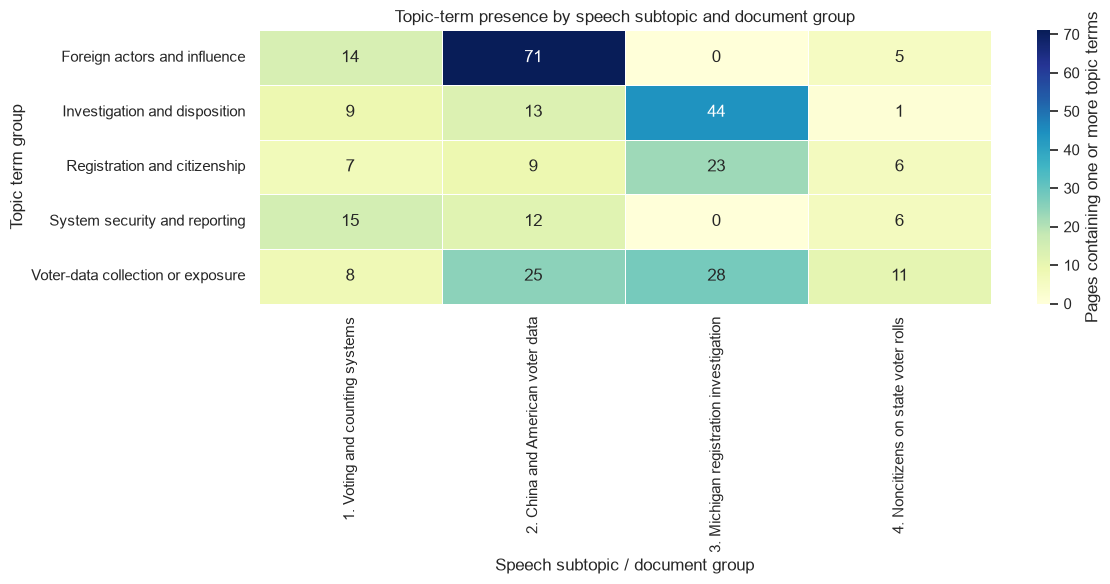

,category,topic,pages_with_topic_terms,share_of_category_pages
4,1. Voting and counting systems,Foreign actors and influence,14,0.538462
9,2. China and American voter data,Foreign actors and influence,71,0.398876
14,3. Michigan registration investigation,Foreign actors and influence,0,0.000000
19,4. Noncitizens on state voter rolls,Foreign actors and influence,5,0.416667
3,1. Voting and counting systems,Investigation and disposition,9,0.346154
8,2. China and American voter data,Investigation and disposition,13,0.073034
13,3. Michigan registration investigation,Investigation and disposition,44,0.830189
18,4. Noncitizens on state voter rolls,Investigation and disposition,1,0.083333
2,1. Voting and counting systems,Registration and citizenship,7,0.269231
7,2. China and American voter data,Registration and citizenship,9,0.050562


In [21]:
TOPIC_PATTERNS = {
    'System security and reporting': r'voting system|voting machine|tabulation|certified results|election infrastructure|vulnerabilit',
    'Voter-data collection or exposure': r'voter registration|voter records|voter files|data acquisition|compromis|exfiltrat',
    'Registration and citizenship': r'registration application|registered to vote|non-citizen|citizenship|ballot|\bvoted\b',
    'Investigation and disposition': r'investigation|referral|interview|declin|prosecution|audit|conclud',
    'Foreign actors and influence': r'\bchina\b|\bprc\b|russia|venezuela|foreign interfer',
}

index_with_category = page_index.merge(
    category_by_path,
    on='source_relative_path',
    how='left',
    validate='many_to_one',
)
topic_rows = []
for category in CATEGORY_ORDER:
    category_pages = index_with_category[index_with_category['category'].eq(category)]
    for topic, pattern in TOPIC_PATTERNS.items():
        pages_matching = category_pages['normalized_text'].str.contains(pattern, regex=True, na=False).sum()
        topic_rows.append({
            'category': CATEGORY_LABELS[category],
            'topic': topic,
            'pages_with_topic_terms': pages_matching,
            'share_of_category_pages': pages_matching / len(category_pages) if len(category_pages) else 0,
        })

topic_summary = pd.DataFrame(topic_rows)
topic_pivot = topic_summary.pivot(index='topic', columns='category', values='pages_with_topic_terms').fillna(0)
topic_pivot = topic_pivot.reindex(columns=[CATEGORY_LABELS[category] for category in CATEGORY_ORDER])
figure, axis = plt.subplots(figsize=(12, 6))
sns.heatmap(topic_pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Pages containing one or more topic terms'}, ax=axis)
axis.set_title('Topic-term presence by speech subtopic and document group')
axis.set_xlabel('Speech subtopic / document group')
axis.set_ylabel('Topic term group')
figure.tight_layout()
save_figure(figure, '03_topic_term_map.png')
plt.show()

display(topic_summary.sort_values(['topic', 'category']))

### Address-to-Corpus Comparison

The July 16, 2026 address introduced four separate subtopics, and each numbered folder is the corresponding document set for one subtopic. The transcript is contextual material, not a substitute for the records.

This comparison looks only for selected terms from the address in the transcript and in each of the four corresponding document groups. The rate is expressed as appearances per 1,000 words, so the much longer document sets can be compared fairly with the shorter speech transcript.

It answers: “Where should I read to compare how this subtopic is discussed in the address and its associated records?” It does **not** answer whether a statement in the address is supported, disproved, or fully addressed by the documents. That determination requires page-level review, careful reading of qualifiers, and, where appropriate, independent corroboration.

The word clouds below are similarly descriptive. They display recurring words after generic release markings and boilerplate are removed. Read them as signposts for navigating each speech subtopic, never as evidence.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\04_address_to_corpus_terms.png


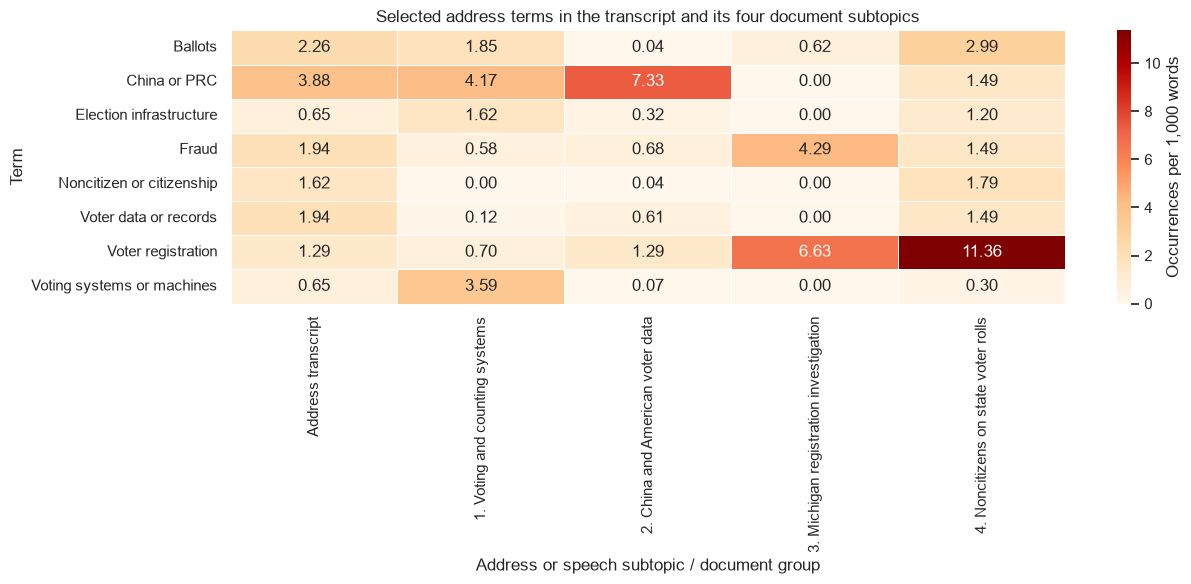

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\05_descriptive_word_clouds.png


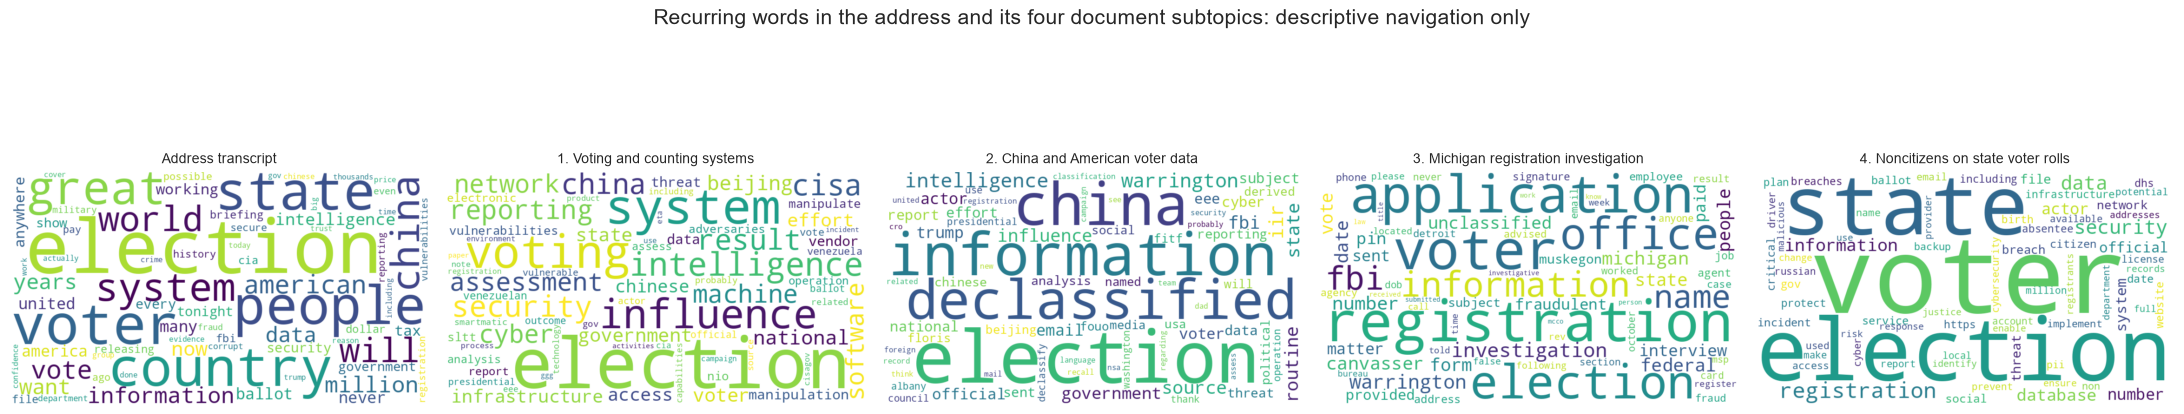

,source,term,occurrences,words,occurrences_per_1000_words
14,1. Voting and counting systems,Ballots,16,8632,1.853568
22,2. China and American voter data,Ballots,1,27818,0.035948
30,3. Michigan registration investigation,Ballots,8,12819,0.624074
38,4. Noncitizens on state voter rolls,Ballots,10,3345,2.989537
6,Address transcript,Ballots,7,3094,2.262443
11,1. Voting and counting systems,China or PRC,36,8632,4.170528
19,2. China and American voter data,China or PRC,204,27818,7.333381
27,3. Michigan registration investigation,China or PRC,0,12819,0.000000
35,4. Noncitizens on state voter rolls,China or PRC,5,3345,1.494768
3,Address transcript,China or PRC,12,3094,3.878474


In [22]:
TRANSCRIPT_PATH = SOURCE_ROOT / 'President Trump Address Transcript - July 16 2026.md'
if not TRANSCRIPT_PATH.is_file():
    raise FileNotFoundError(f'Missing transcript: {TRANSCRIPT_PATH}')

transcript_lines = TRANSCRIPT_PATH.read_text(encoding='utf-8').splitlines()
spoken_lines = [
    re.sub(r'^\[\d{2}:\d{2}:\d{2}\]\s*', '', line).strip()
    for line in transcript_lines
    if line.startswith('[')
]
transcript_text = ' '.join(spoken_lines)

comparison_texts = {'Address transcript': transcript_text}
for category in CATEGORY_ORDER:
    category_text = index_with_category.loc[
        index_with_category['category'].eq(category), 'extracted_text'
    ].str.cat(sep=' ')
    comparison_texts[CATEGORY_LABELS[category]] = category_text

ADDRESS_TERMS = {
    'Election infrastructure': r'election infrastructure',
    'Voter registration': r'voter registration',
    'Voter data or records': r'voter (?:data|records|files)',
    'China or PRC': r'\b(?:china|prc)\b',
    'Noncitizen or citizenship': r'non-citizen|noncitizen|citizenship',
    'Voting systems or machines': r'voting (?:system|systems|machine|machines)',
    'Ballots': r'\bballot(?:s)?\b',
    'Fraud': r'\bfraud(?:ulent)?\b',
}

comparison_rows = []
for source_name, text in comparison_texts.items():
    word_count = len(re.findall(r"[A-Za-z][A-Za-z'-]*", text))
    for term, pattern in ADDRESS_TERMS.items():
        count = len(re.findall(pattern, text, flags=re.IGNORECASE))
        comparison_rows.append({
            'source': source_name,
            'term': term,
            'occurrences': count,
            'words': word_count,
            'occurrences_per_1000_words': (count / word_count * 1000) if word_count else 0,
        })

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(REGISTRY_ROOT / 'address_corpus_term_comparison.csv', index=False)
comparison_pivot = comparison.pivot(index='term', columns='source', values='occurrences_per_1000_words').fillna(0)
comparison_pivot = comparison_pivot.reindex(columns=['Address transcript'] + [CATEGORY_LABELS[category] for category in CATEGORY_ORDER])
figure, axis = plt.subplots(figsize=(13, 6))
sns.heatmap(comparison_pivot, annot=True, fmt='.2f', cmap='OrRd', linewidths=.5, cbar_kws={'label': 'Occurrences per 1,000 words'}, ax=axis)
axis.set_title('Selected address terms in the transcript and its four document subtopics')
axis.set_xlabel('Address or speech subtopic / document group')
axis.set_ylabel('Term')
figure.tight_layout()
save_figure(figure, '04_address_to_corpus_terms.png')
plt.show()

def clean_words(text):
    return re.findall(r"[a-z]{3,}", text.casefold())

extra_stopwords = {
    'approved', 'public', 'release', 'released', 'counsel', 'president', 'july', 'june',
    'page', 'pages', 'document', 'documents', 'marked', 'redacted', 'classified', 'declass',
    'also', 'would', 'could', 'shall', 'may', 'must', 'one', 'two', 'three', 'u', 'us',
}
stopwords = STOPWORDS.union(extra_stopwords)
wordcloud_sources = {'Address transcript': transcript_text}
wordcloud_sources.update({CATEGORY_LABELS[category]: comparison_texts[CATEGORY_LABELS[category]] for category in CATEGORY_ORDER})

figure, axes = plt.subplots(1, len(wordcloud_sources), figsize=(22, 5))
for axis, (source_name, text) in zip(axes, wordcloud_sources.items()):
    usable_text = ' '.join(word for word in clean_words(text) if word not in stopwords)
    cloud = WordCloud(width=900, height=500, background_color='white', colormap='viridis', max_words=70, collocations=False, stopwords=stopwords).generate(usable_text or 'no readable text')
    axis.imshow(cloud, interpolation='bilinear')
    axis.set_title(source_name, fontsize=10)
    axis.axis('off')
figure.suptitle('Recurring words in the address and its four document subtopics: descriptive navigation only', y=1.02, fontsize=15)
figure.tight_layout()
save_figure(figure, '05_descriptive_word_clouds.png')
plt.show()

display(comparison.sort_values(['term', 'source']))

## Traceability and Review Dashboard

This section connects the four speech subtopics to the folders, documents, page counts, OCR burden, and eventual source-checked claims. It is a guide to the research record, not an assessment of whether an assertion is true.

The chart will initially show zero reviewed claims because the claim ledger is deliberately empty until a reviewer checks the original PDF page and enters a quotation. As claims are added, rerunning this section updates the counts automatically.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\06_speech_subtopic_traceability.png


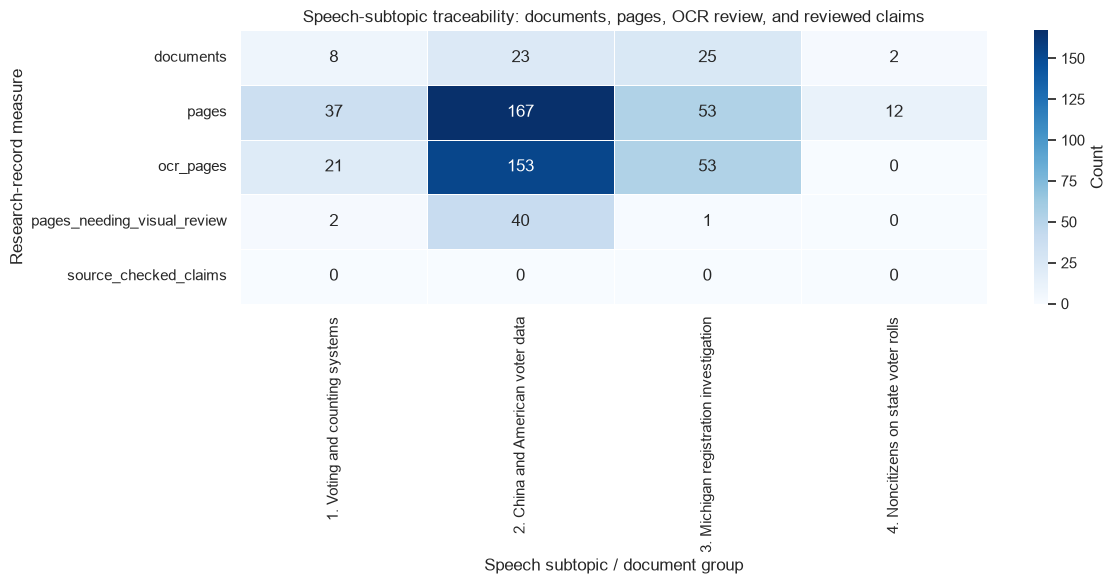

,speech_subtopic,document_folder,documents,pages,ocr_pages,pages_needing_visual_review,source_checked_claims
0,1. Voting and counting systems,1. Vulnerabilities in Voting and Counting Systems,8,37,21,2,0
1,2. China and American voter data,2. ChinaAcquisitionExploitationAmericanVoterData,23,167,153,40,0
2,3. Michigan registration investigation,3. MichiganVoterRegistrationInvestigation,25,53,53,1,0
3,4. Noncitizens on state voter rolls,4. Noncitizens on State Voter Rolls,2,12,0,0,0


In [9]:
def read_csv_or_empty(path, columns):
    if not path.is_file() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    return pd.read_csv(path)

claim_ledger = read_csv_or_empty(REGISTRY_ROOT / 'claim_ledger.csv', CLAIM_COLUMNS)
claim_categories = claim_ledger.merge(
    category_by_path,
    on='source_relative_path',
    how='left',
    validate='many_to_one',
) if not claim_ledger.empty else pd.DataFrame(columns=['category'])

traceability = (
    page_visual.groupby('category')
    .agg(
        documents=('source_relative_path', 'nunique'),
        pages=('page_number', 'size'),
        ocr_pages=('extraction_method', lambda values: values.eq('ocr').sum()),
        pages_needing_visual_review=('review_required', 'sum'),
    )
    .reindex(CATEGORY_ORDER, fill_value=0)
)
reviewed_claims = claim_categories.groupby('category').size().reindex(CATEGORY_ORDER, fill_value=0)
traceability['source_checked_claims'] = reviewed_claims
traceability['speech_subtopic'] = [CATEGORY_LABELS[category] for category in traceability.index]
traceability['document_folder'] = [SPEECH_TOPIC_MAP[category]['folder'] for category in traceability.index]
traceability = traceability.reset_index(names='category')
traceability.to_csv(REGISTRY_ROOT / 'speech_subtopic_traceability.csv', index=False)

figure, axis = plt.subplots(figsize=(12, 6))
plot_data = traceability.set_index('speech_subtopic')[['documents', 'pages', 'ocr_pages', 'pages_needing_visual_review', 'source_checked_claims']]
sns.heatmap(plot_data.T, annot=True, fmt='.0f', cmap='Blues', linewidths=.5, cbar_kws={'label': 'Count'}, ax=axis)
axis.set_title('Speech-subtopic traceability: documents, pages, OCR review, and reviewed claims')
axis.set_xlabel('Speech subtopic / document group')
axis.set_ylabel('Research-record measure')
figure.tight_layout()
save_figure(figure, '06_speech_subtopic_traceability.png')
plt.show()

display(traceability[['speech_subtopic', 'document_folder', 'documents', 'pages', 'ocr_pages', 'pages_needing_visual_review', 'source_checked_claims']])

### OCR Review Progress

This dashboard tracks the quality-control step between OCR and quotation. A page is not automatically unsuitable because it is flagged. It simply needs a visual comparison with the original PDF before an analyst relies on its wording, names, numbers, or date references.

The decision sheet is stored locally in `evidence_registry/ocr_review_decisions.csv`. Update its review fields, rerun this cell, and the chart will show progress.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\07_ocr_review_progress.png


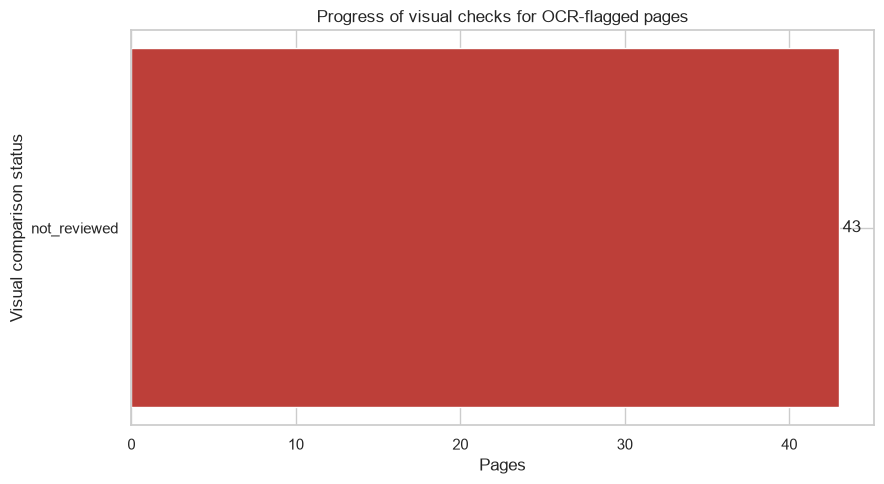

,visual_comparison_status,pages
0,not_reviewed,43


In [10]:
ocr_review_progress = read_csv_or_empty(REGISTRY_ROOT / 'ocr_review_decisions.csv', OCR_REVIEW_COLUMNS)
if ocr_review_progress.empty:
    ocr_review_progress = pd.DataFrame({'visual_comparison_status': ['no_review_rows'], 'pages': [0]})
else:
    ocr_review_progress['visual_comparison_status'] = ocr_review_progress['visual_comparison_status'].fillna('not_reviewed')
    ocr_review_progress = ocr_review_progress.groupby('visual_comparison_status').size().rename('pages').reset_index()

status_order = ['not_reviewed', 'source_page_checked', 'needs_correction', 'unsuitable_for_quotation']
ocr_review_progress['status_order'] = ocr_review_progress['visual_comparison_status'].map({status: position for position, status in enumerate(status_order)}).fillna(len(status_order))
ocr_review_progress = ocr_review_progress.sort_values('status_order')
status_colors = {'not_reviewed': '#bd3f39', 'source_page_checked': '#397a55', 'needs_correction': '#d48a38', 'unsuitable_for_quotation': '#72528c'}
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    ocr_review_progress['visual_comparison_status'],
    ocr_review_progress['pages'],
    color=[status_colors.get(status, '#777777') for status in ocr_review_progress['visual_comparison_status']],
)
axis.set_title('Progress of visual checks for OCR-flagged pages')
axis.set_xlabel('Pages')
axis.set_ylabel('Visual comparison status')
for position, count in enumerate(ocr_review_progress['pages']):
    axis.text(count + 0.25, position, str(count), va='center')
figure.tight_layout()
save_figure(figure, '07_ocr_review_progress.png')
plt.show()

display(ocr_review_progress[['visual_comparison_status', 'pages']])

### Certainty and Limitation Language

This chart marks pages that contain selected terms expressing uncertainty, attribution, confirmation, or limitation. It measures how sources phrase statements; it does not decide how credible a statement is.

For example, `assess` and `likely` signal an assessment rather than a confirmed event. `confirmed` may refer to a narrow fact, not every surrounding assertion. Read the original page and its context before assigning an evidentiary status.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\08_certainty_and_limitation_language.png


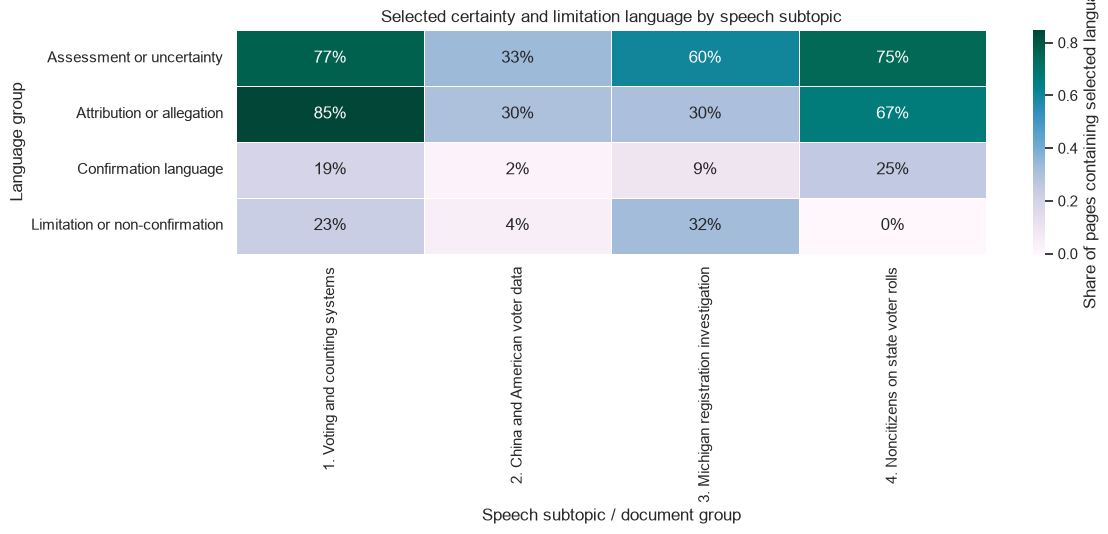

,speech_subtopic,language_group,pages_with_terms,share_of_pages
1,1. Voting and counting systems,Assessment or uncertainty,20,0.769231
5,2. China and American voter data,Assessment or uncertainty,59,0.331461
9,3. Michigan registration investigation,Assessment or uncertainty,32,0.603774
13,4. Noncitizens on state voter rolls,Assessment or uncertainty,9,0.750000
0,1. Voting and counting systems,Attribution or allegation,22,0.846154
4,2. China and American voter data,Attribution or allegation,53,0.297753
8,3. Michigan registration investigation,Attribution or allegation,16,0.301887
12,4. Noncitizens on state voter rolls,Attribution or allegation,8,0.666667
2,1. Voting and counting systems,Confirmation language,5,0.192308
6,2. China and American voter data,Confirmation language,4,0.022472


In [12]:
CERTAINTY_PATTERNS = {
    'Attribution or allegation': r'\balleg(?:ed|ation)|\breport(?:ed|ing)?\b|\bclaim(?:ed|s)?\b',
    'Assessment or uncertainty': r'\bassess(?:ed|ment)?\b|\blikely\b|\bmay\b|\bmight\b|\bcould\b|\bpossible\b',
    'Confirmation language': r'\bconfirm(?:ed|ation)?\b|\bverified\b|\bestablished\b',
    'Limitation or non-confirmation': r'\bunconfirmed\b|\bdid not\b|\bunable to\b|\blimited sourc|\bnot definitively\b',
}
index_with_category_for_certainty = page_index.merge(
    category_by_path,
    on='source_relative_path',
    how='left',
    validate='many_to_one',
)
certainty_rows = []
for category in CATEGORY_ORDER:
    category_pages = index_with_category_for_certainty[index_with_category_for_certainty['category'].eq(category)]
    for label, pattern in CERTAINTY_PATTERNS.items():
        count = category_pages['normalized_text'].str.contains(pattern, regex=True, na=False).sum()
        certainty_rows.append({
            'speech_subtopic': CATEGORY_LABELS[category],
            'language_group': label,
            'pages_with_terms': count,
            'share_of_pages': count / len(category_pages) if len(category_pages) else 0,
        })
certainty_summary = pd.DataFrame(certainty_rows)
certainty_pivot = certainty_summary.pivot(index='language_group', columns='speech_subtopic', values='share_of_pages').fillna(0)
certainty_pivot = certainty_pivot.reindex(columns=[CATEGORY_LABELS[category] for category in CATEGORY_ORDER])
figure, axis = plt.subplots(figsize=(12, 5.5))
sns.heatmap(certainty_pivot, annot=True, fmt='.0%', cmap='PuBuGn', linewidths=.5, cbar_kws={'label': 'Share of pages containing selected language'}, ax=axis)
axis.set_title('Selected certainty and limitation language by speech subtopic')
axis.set_xlabel('Speech subtopic / document group')
axis.set_ylabel('Language group')
figure.tight_layout()
save_figure(figure, '08_certainty_and_limitation_language.png')
plt.show()
certainty_summary.to_csv(REGISTRY_ROOT / 'certainty_language_summary.csv', index=False)
display(certainty_summary.sort_values(['language_group', 'speech_subtopic']))

### Shared Documents Across Speech Subtopics

Three source files appear in both the first and second folders. They are byte-identical, so they should be read once but may be relevant to more than one speech subtopic.

This diagram represents organization and reuse only. A shared document is not independent corroboration, and it must not be counted twice when weighing support for a proposition.

Saved: C:\Users\pchri\Documents\ChrisStuff\WhitehouseDotGov\evidence_registry\visualizations\09_shared_document_relationships.png


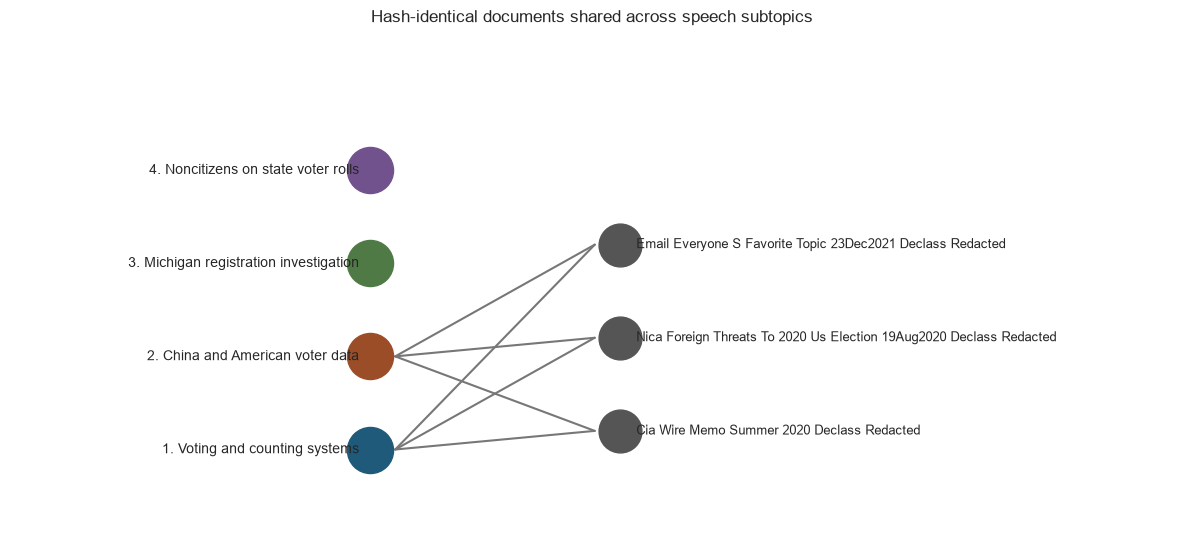

,speech_subtopics,copies,document_paths
0,2. China and American voter data | 1. Voting a...,2,2. ChinaAcquisitionExploitationAmericanVoterDa...
1,2. China and American voter data | 1. Voting a...,2,2. ChinaAcquisitionExploitationAmericanVoterDa...
2,2. China and American voter data | 1. Voting a...,2,2. ChinaAcquisitionExploitationAmericanVoterDa...


In [13]:
duplicate_groups = documents.groupby('source_sha256').filter(lambda group: len(group) > 1).copy()
duplicate_summary = (
    duplicate_groups.groupby('source_sha256')
    .agg(
        document_id=('document_id', 'first'),
        document_paths=('source_relative_path', lambda values: ' | '.join(values)),
        speech_subtopics=('category', lambda values: ' | '.join(CATEGORY_LABELS[category] for category in values)),
        copies=('category', 'size'),
    )
    .reset_index()
)
duplicate_summary.to_csv(REGISTRY_ROOT / 'shared_document_map.csv', index=False)

if duplicate_summary.empty:
    print('No hash-identical documents occur across the speech subtopics.')
else:
    subtopic_positions = {category: index for index, category in enumerate(CATEGORY_ORDER)}
    figure, axis = plt.subplots(figsize=(12, 5.5))
    for category, position in subtopic_positions.items():
        axis.scatter(0, position, s=1100, color=CATEGORY_COLORS[category], zorder=3)
        axis.text(-0.08, position, CATEGORY_LABELS[category], ha='right', va='center', fontsize=10)
    for duplicate_index, row in duplicate_summary.reset_index(drop=True).iterrows():
        x_position = 1.8
        y_position = duplicate_index + 0.2
        document_label = row['document_id'].rsplit('_', 1)[0].replace('_', ' ').title()
        axis.scatter(x_position, y_position, s=950, color='#555555', zorder=3)
        axis.text(x_position + 0.12, y_position, document_label, ha='left', va='center', fontsize=9)
        linked_categories = duplicate_groups.loc[duplicate_groups['source_sha256'].eq(row['source_sha256']), 'category'].tolist()
        for category in linked_categories:
            axis.plot([0.18, x_position - 0.18], [subtopic_positions[category], y_position], color='#777777', linewidth=1.5, zorder=1)
    axis.set_title('Hash-identical documents shared across speech subtopics')
    axis.set_xlim(-2.6, 5.8)
    axis.set_ylim(-0.8, max(len(CATEGORY_ORDER), len(duplicate_summary)) + 0.5)
    axis.axis('off')
    figure.tight_layout()
    save_figure(figure, '09_shared_document_relationships.png')
    plt.show()
    display(duplicate_summary[['speech_subtopics', 'copies', 'document_paths']])

### Source-Checked Event Timeline

This timeline activates only after `events.csv` contains events linked to claims in the local ledger. It intentionally does not derive dates automatically from OCR text: an OCR date may be wrong, a date can refer to a report rather than an event, and a source can describe an allegation rather than an established occurrence.

For each event, enter a date or date range, neutral description, jurisdiction, event type, and the associated claim ID after checking the source page. The timeline then becomes a chronology of reviewed entries, with a direct link back to the claim registry.

In [16]:
events = read_csv_or_empty(REGISTRY_ROOT / 'events.csv', EVENT_COLUMNS)
if events.empty:
    print('No source-checked events are recorded yet. Add reviewed events to evidence_registry/events.csv to populate this timeline.')
else:
    event_claims = events.merge(
        claim_ledger[['claim_id', 'source_relative_path', 'review_status', 'evidentiary_status']],
        left_on='source_claim_id',
        right_on='claim_id',
        how='left',
    )
    event_claims = event_claims.merge(
        category_by_path,
        on='source_relative_path',
        how='left',
    )
    event_claims['parsed_date'] = pd.to_datetime(event_claims['event_date_or_range'], errors='coerce')
    timeline_ready = event_claims[event_claims['parsed_date'].notna()].sort_values('parsed_date').copy()
    unparsed = event_claims[event_claims['parsed_date'].isna()].copy()
    if timeline_ready.empty:
        print('Events exist, but none use a machine-sortable date. Use ISO dates such as 2020-08-19 where possible.')
    else:
        timeline_dates = pd.to_datetime(timeline_ready['parsed_date']).dt.to_pydatetime()
        y_positions = list(range(len(timeline_ready)))
        category_labels = [CATEGORY_LABELS.get(str(category), str(category)) for category in timeline_ready['category'].fillna('unassigned')]
        figure, axis = plt.subplots(figsize=(12, max(4, len(timeline_ready) * 0.65)))
        colors = [CATEGORY_COLORS.get(str(category), '#777777') for category in timeline_ready['category'].fillna('unassigned')]
        axis.scatter(timeline_dates, y_positions, s=100, color=colors, zorder=3)
        first_date = min(timeline_dates)
        for y_position, event_date, row in zip(y_positions, timeline_dates, timeline_ready.itertuples(index=False)):
            axis.hlines(y_position, first_date, event_date, color='#cccccc', linewidth=1, zorder=1)
            axis.annotate(f'{row.event_type}: {row.description}', xy=(event_date, y_position), xytext=(4, 8), textcoords='offset points', fontsize=9, ha='left', va='bottom')
        axis.set_yticks(y_positions, category_labels)
        axis.set_title('Timeline of source-checked events entered in the registry')
        axis.set_xlabel('Event date')
        axis.set_ylabel('Speech subtopic / document group')
        figure.autofmt_xdate()
        figure.tight_layout()
        save_figure(figure, '10_source_checked_event_timeline.png')
        plt.show()
        display(timeline_ready[['event_date_or_range', 'event_type', 'description', 'jurisdiction', 'source_claim_id', 'review_status', 'evidentiary_status']])
    if not unparsed.empty:
        print('Events awaiting a machine-sortable date:')
        display(unparsed[['event_date_or_range', 'event_type', 'description', 'source_claim_id']])

No source-checked events are recorded yet. Add reviewed events to evidence_registry/events.csv to populate this timeline.
